<a href="https://colab.research.google.com/github/bootstrap666/covidbr-data/blob/main/COVID_19_linear_MA_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import signal

In [47]:
url = 'https://github.com/bootstrap666/covidbr-data/raw/refs/heads/main/HIST_PAINEL_COVIDBR.csv'

df = pd.concat([chunk for chunk in tqdm(pd.read_csv(url, sep=';', chunksize=1000), desc='Loading data')])
print(df.head(5))

Loading data: 11178it [00:20, 548.37it/s]


   regiao estado municipio  coduf  codmun  codRegiaoSaude nomeRegiaoSaude  \
0  Brasil    NaN       NaN     76     NaN             NaN             NaN   
1  Brasil    NaN       NaN     76     NaN             NaN             NaN   
2  Brasil    NaN       NaN     76     NaN             NaN             NaN   
3  Brasil    NaN       NaN     76     NaN             NaN             NaN   
4  Brasil    NaN       NaN     76     NaN             NaN             NaN   

         data  semanaEpi  populacaoTCU2019  casosAcumulado  casosNovos  \
0  2020-02-25          9       210147125.0             0.0           0   
1  2020-02-26          9       210147125.0             1.0           1   
2  2020-02-27          9       210147125.0             1.0           0   
3  2020-02-28          9       210147125.0             1.0           0   
4  2020-02-29          9       210147125.0             2.0           1   

   obitosAcumulado  obitosNovos  Recuperadosnovos  emAcompanhamentoNovos  \
0               

Text(0.5, 0, 'dia')

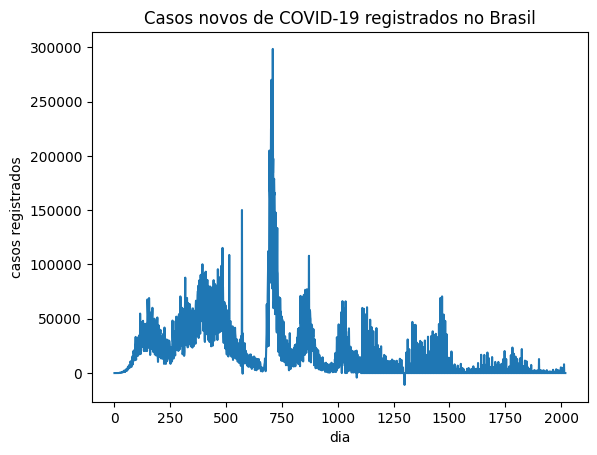

In [48]:
Brasildados = df[df['regiao']=='Brasil']
Brasildados = Brasildados.sort_values(by='data')
Brasilcasosnovos = Brasildados['casosNovos'].to_numpy()

plt.plot( Brasilcasosnovos)
plt.title ('Casos novos de COVID-19 registrados no Brasil')
plt.ylabel('casos registrados')
plt.xlabel('dia')

In [84]:
N = 64
fc = 1/20

hideal = 2*fc* np.sinc(2*fc*np.arange(-N/2,N/2))
janela = np.blackman(N)
h = hideal*janela

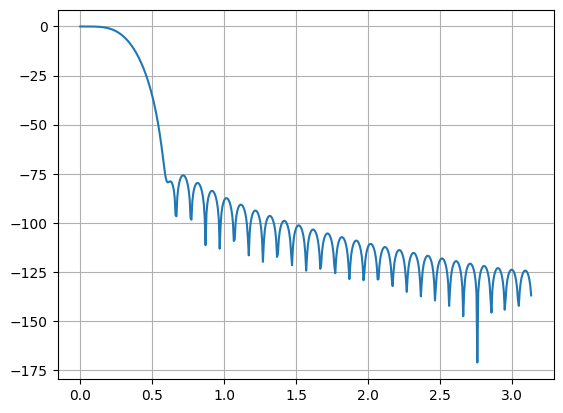

In [85]:
W,H = signal.freqz(h)
plt.plot(W,20*np.log10(abs(H)))
plt.grid('minor')

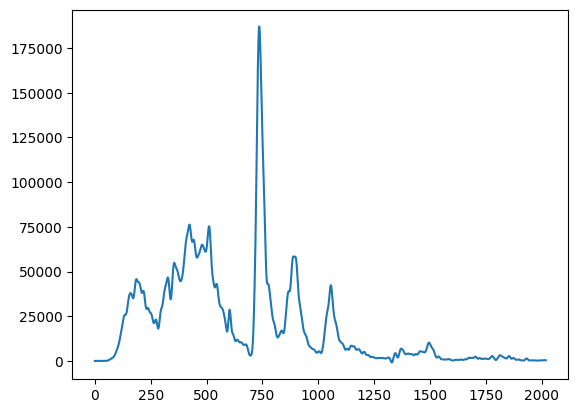

In [86]:
Brasilcasosnovosfiltrado = signal.lfilter(h,1,Brasilcasosnovos)
plt.plot(Brasilcasosnovosfiltrado)

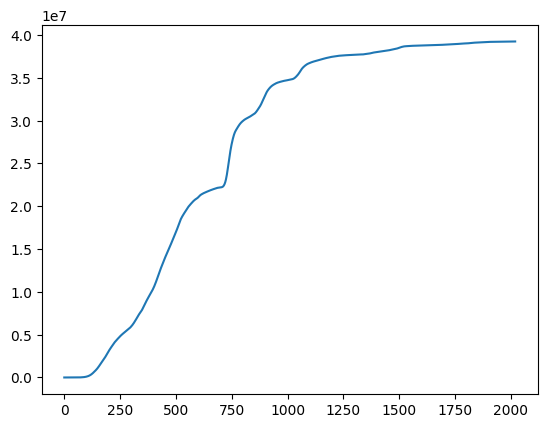

In [108]:
BrasilcasosAcumulados = signal.lfilter(1,[1, -1],Brasilcasosnovosfiltrado)
plt.plot(BrasilcasosAcumulados)

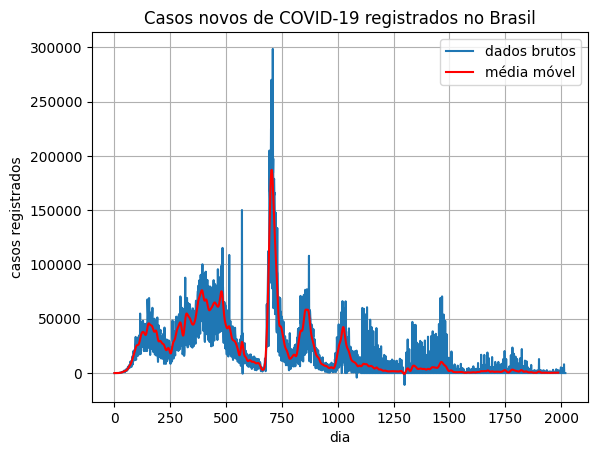

In [87]:
plt.plot( Brasilcasosnovos, label='dados brutos')
plt.plot( Brasilcasosnovosfiltrado[(N//2):], 'r', label='média móvel')
plt.title ('Casos novos de COVID-19 registrados no Brasil')
plt.ylabel('casos registrados')
plt.xlabel('dia')
plt.grid("minor")
plt.legend()

In [88]:
RSdados = df[df['estado']=='RS']
RSdados = RSdados[RSdados['municipio'].isnull()]
RSdados = RSdados[RSdados['codmun'].isnull()]
RSdados = RSdados.sort_values(by='data')
RScasosnovos = RSdados['casosNovos'].to_numpy()

RScasosnovosfiltrado = signal.lfilter(h,1,RScasosnovos)

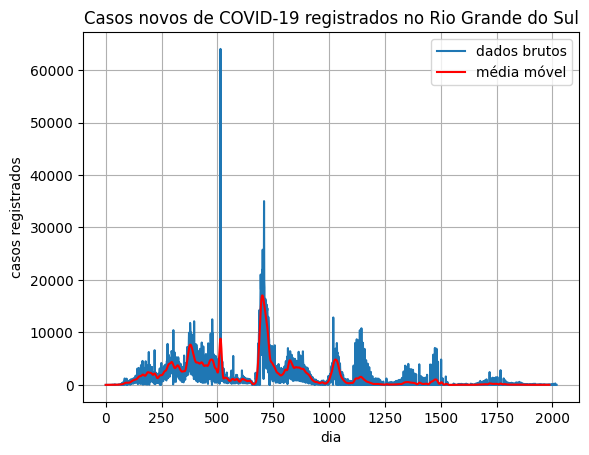

In [89]:
plt.plot( RScasosnovos, label='dados brutos')
plt.plot( RScasosnovosfiltrado[(N//2):], 'r', label='média móvel')
plt.title ('Casos novos de COVID-19 registrados no Rio Grande do Sul')
plt.ylabel('casos registrados')
plt.xlabel('dia')
plt.grid("minor")
plt.legend()

In [104]:
SMdados = df[df['estado']=='RS']
SMdados = SMdados[SMdados['municipio']=='Santa Maria']
SMdados = SMdados.sort_values(by='data')
SMcasosnovos = SMdados['obitosNovos'].to_numpy()

SMcasosnovosfiltrado = signal.lfilter(h,1,SMcasosnovos)

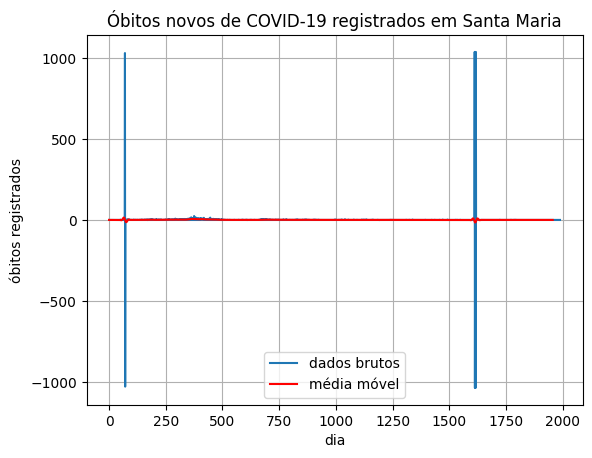

In [105]:
plt.plot( SMcasosnovos, label='dados brutos')
plt.plot( SMcasosnovosfiltrado[(N//2):], 'r', label='média móvel')
plt.title ('Óbitos novos de COVID-19 registrados em Santa Maria')
plt.ylabel('óbitos registrados')
plt.xlabel('dia')
plt.grid("minor")
plt.legend()

In [106]:
print(SMdados.head(4000))

         regiao estado    municipio  coduf    codmun  codRegiaoSaude  \
638027      Sul     RS  Santa Maria     43  431690.0         43001.0   
638028      Sul     RS  Santa Maria     43  431690.0         43001.0   
638029      Sul     RS  Santa Maria     43  431690.0         43001.0   
638030      Sul     RS  Santa Maria     43  431690.0         43001.0   
638031      Sul     RS  Santa Maria     43  431690.0         43001.0   
...         ...    ...          ...    ...       ...             ...   
11136787    Sul     RS  Santa Maria     43  431690.0         43001.0   
11136788    Sul     RS  Santa Maria     43  431690.0         43001.0   
11136789    Sul     RS  Santa Maria     43  431690.0         43001.0   
11136790    Sul     RS  Santa Maria     43  431690.0         43001.0   
11136791    Sul     RS  Santa Maria     43  431690.0         43001.0   

         nomeRegiaoSaude        data  semanaEpi  populacaoTCU2019  \
638027         REGIAO 01  2020-03-27         13          282123.0 

In [107]:
SMdados.to_csv('SantaMaria.csv', index=False)